In [ ]:
import numpy as np
import pandas as pd


In [ ]:
data = pd.read_csv('HR_Employee Analysis.csv')

In [ ]:
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
# 1.  Missing Value Check (Data Quality Check)

data.info()   # As per info fetched there is no Missing value in data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
data.isna().any() | data.eq('').any()  # Double check for all column , if any Missing value is there (No Missing value observed)

,0
satisfaction_level,False
last_evaluation,False
number_project,False
average_montly_hours,False
time_spend_company,False
Work_accident,False
left,False
promotion_last_5years,False
Department,False
salary,False


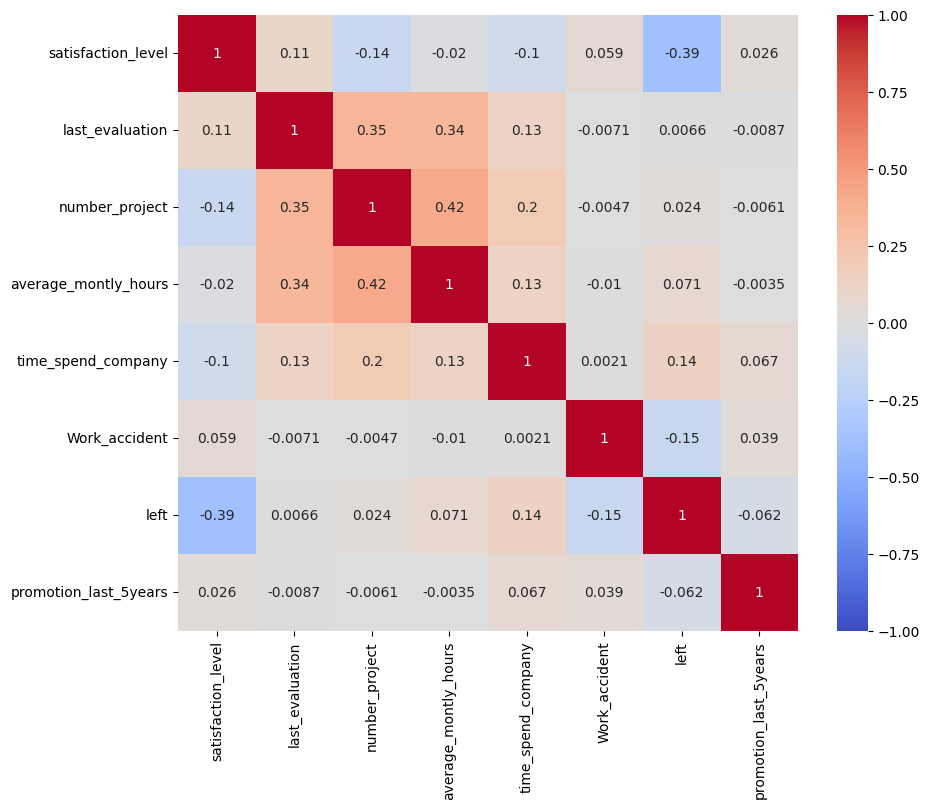

In [ ]:
# 2. Understand what factor contributed most to employee turnover at EDA .

# 2.1 ---> Draw Heat map of all  Correlation Matrix between all numerical features or columns in the data .

import seaborn as sns
import matplotlib.pyplot as plt

corr = data.corr(numeric_only=True)

plt.figure(figsize=(10 , 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()


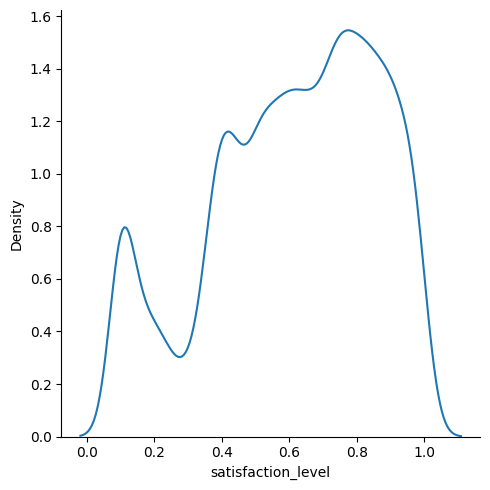

In [ ]:
# 2.2 -- Draw the distribution plot

# A. Employee Satisfaction

sns.displot(data['satisfaction_level'], kind='kde')

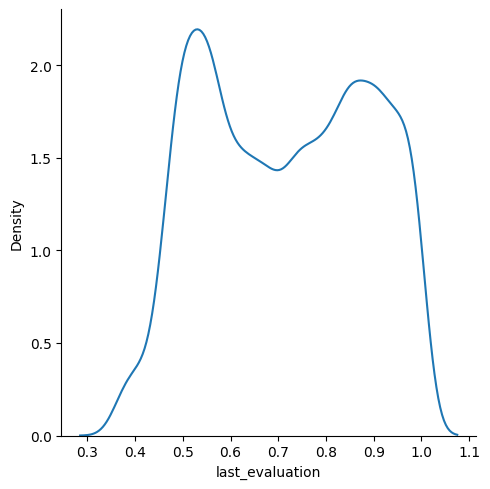

In [ ]:
# Employee Evaluation
sns.displot(data['last_evaluation'], kind='kde')

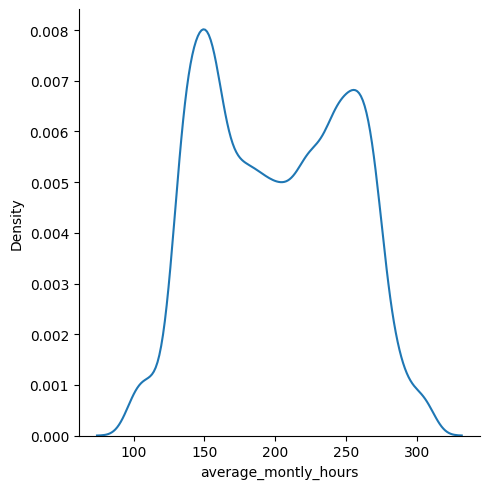

In [ ]:
# Employee Monthly Average hourls

sns.displot(data['average_montly_hours'], kind='kde')

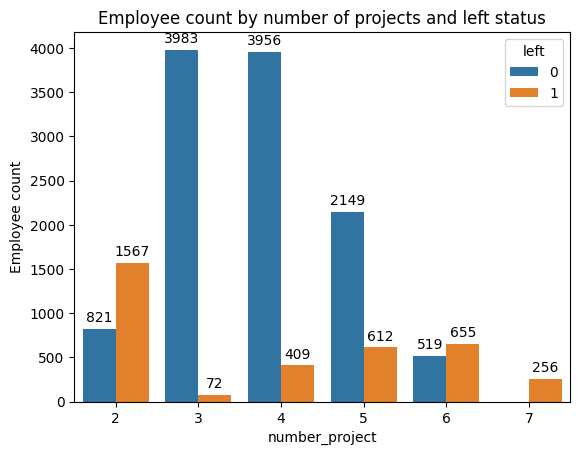

In [ ]:
# 2.3 Bar plot between 'Number of Project' and 'Employee stay or left'

ax = sns.countplot(data=data, x='number_project', hue='left')
ax.set_title('Employee count by number of projects and left status')
ax.set_ylabel('Employee count')

for container in ax.containers:
  ax.bar_label(container , padding=3)

plt.show()

In [ ]:
# Inference from the Plot

# Positive side first ===> Employee having 3 & 4 and very less in % who left Job
# Employee having 5 project in hand should not give additional project as chances are high he will left job
# High %age of Employee left organization when they have <3 number of Project
# Also ver high %age of Employee left when they have >5 number of Project in hand


In [ ]:
# 3. Perform clustering of employee who left based on their satisfaction and evaluation

# 3.1.	Choose columns satisfaction_level, last_evaluation, and left.

column_combine = ['satisfaction_level' , 'last_evaluation' , 'left']

subset = data[column_combine]
subset.head()

,satisfaction_level,last_evaluation,left
0,0.38,0.53,1
1,0.80,0.86,1
2,0.11,0.88,1
3,0.72,0.87,1
4,0.37,0.52,1


In [ ]:
# 3.2 -->	Do K-means clustering of employees who left the company into 3 clusters?

# Filter employee who left company in 3 cluster

left_emp = data[['satisfaction_level', 'last_evaluation',]][data['left'] == 1]
left_emp.head()

,satisfaction_level,last_evaluation
0,0.38,0.53
1,0.80,0.86
2,0.11,0.88
3,0.72,0.87
4,0.37,0.52


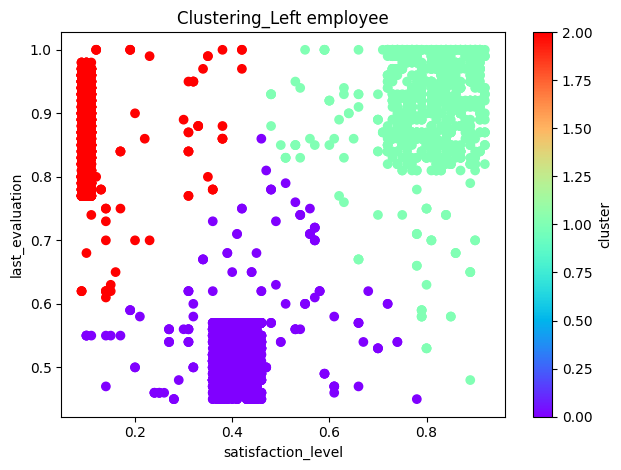

In [ ]:
# Run K means with 3 Cluster

from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=3 , random_state=42)

k_means.fit(left_emp)

left_emp['cluster'] = k_means.labels_


# Visualize Clustering

import matplotlib.pyplot as plt

plt.scatter(left_emp['satisfaction_level'], left_emp['last_evaluation'], c=left_emp['cluster'], cmap='rainbow')
plt.xlabel('satisfaction_level')
plt.ylabel('last_evaluation')
plt.title('Clustering_Left employee')
plt.colorbar(label='cluster')
plt.tight_layout()
plt.show()

In [ ]:
# 3.3.	Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.

# Clsuter divided in 3 categories ,
#     1. Low satisfaction level with High evaluation
#     2. Satisfaciotn levle and evalution both are moderate
#     3. High satisfaction level with High evaluation

# If we talk about Inference from the data , all type of employee are left job there is no fix type of employee category which left job due to satisfaction level or Evalution

In [ ]:
# 4.	Handle the left Class Imbalance using the SMOTE technique.

# 4.1	Pre-process the data by converting categorical columns to numerical columns by:
#      ■	Separating categorical variables and numeric variables
#      ■	Applying get_dummies() to the categorical variables
#      ■	Combining categorical variables and numeric variables

In [ ]:
#      ■	Separating categorical variables and numeric variables

num_cols = data.select_dtypes(include=np.number).columns
cat_cols = data.select_dtypes(exclude=np.number).columns

num_cols, cat_cols

(Index(['satisfaction_level', 'last_evaluation', 'number_project',
        'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
        'promotion_last_5years'],
       dtype='object'),
 Index(['Department', 'salary'], dtype='object'))

In [ ]:
# ■	Applying get_dummies() to the categorical variables

dept_dummies = pd.get_dummies(data['Department'], prefix='Department', drop_first=True)
salary_dummies = pd.get_dummies(data['salary'], prefix='salary', drop_first=True)

# ■	Combining categorical variables and numeric variables
data_num = data.drop(['Department' , 'salary'], axis=1)
data_final = pd.concat([data_num, dept_dummies, salary_dummies], axis=1)


In [ ]:
# 4.2.Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.

from sklearn.model_selection import train_test_split

X = data_final.drop('left', axis=1)
y = data_final['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

#
# 4.3.	Upsample the train dataset using the SMOTE technique from the imblearn module.

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=123)
X_train_smt , y_train_smt = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n",  y_train_smt.value_counts())  # Check for before and after SMOTE for balanced Training set

Before SMOTE:
 left
0    9142
1    2857
Name: count, dtype: int64

After SMOTE:
 left
0    9142
1    9142
Name: count, dtype: int64


In [ ]:
# 5.	Perform 5-fold cross-validation model training and evaluate performance.
#      5.1. Train a logistic regression model, apply a 5-fold CV, and plot the classification report.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict , StratifiedKFold
from sklearn.metrics import classification_report

# Define CV strategy (5 folds, stratified)

cv = StratifiedKFold(n_splits = 5, shuffle=True, random_state=123)

# Train logistic regression with 5‑fold CV and get predictions
# Use the SMOTE output (X_train_sm, y_train_sm) here:

log_reg = LogisticRegression(max_iter=1000 , solver='liblinear') #good for binary , small dataset

y_train_pred_cv = cross_val_predict(log_reg, X_train_smt, y_train_smt, cv=cv, method='predict')

print("Logistic Regression – 5-fold CV on SMOTE-balanced training set")
print(classification_report(y_train_smt, y_train_pred_cv, digits=3))



Logistic Regression – 5-fold CV on SMOTE-balanced training set
              precision    recall  f1-score   support

           0      0.810     0.771     0.790      9142
           1      0.781     0.819     0.800      9142

    accuracy                          0.795     18284
   macro avg      0.796     0.795     0.795     18284
weighted avg      0.796     0.795     0.795     18284



In [ ]:
# 5.2.	Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.

# Import Random Forest and CV tools

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report

# Define the 5‑fold stratified CV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Define and evaluate the Random Forest with 5‑fold CV

rf_clf = RandomForestClassifier(n_estimators=101, max_depth=None, random_state=123, n_jobs=-1)

# out-of-fold predictions for each sample in the (SMOTE) training set

y_train_pred_cv = cross_val_predict(rf_clf, X_train_smt, y_train_smt, cv=cv, method='predict')

print("Random Forest – 5-fold CV on SMOTE-balanced training set")
print(classification_report(y_train_smt, y_train_pred_cv, digits=3))


Random Forest – 5-fold CV on SMOTE-balanced training set
              precision    recall  f1-score   support

           0      0.975     0.995     0.985      9142
           1      0.995     0.975     0.985      9142

    accuracy                          0.985     18284
   macro avg      0.985     0.985     0.985     18284
weighted avg      0.985     0.985     0.985     18284



In [ ]:
#5.3.	Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.

# Import Gradient Boosting and CV tools

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report

# Define the 5‑fold stratified CV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Define and evaluate the Gradient Boosting model

gb_clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=123)

# Out-of-fold predictions for each sample in the SMOTE training set

y_train_pred_cv_gb = cross_val_predict(gb_clf, X_train_smt, y_train_smt, cv=cv, method='predict')

print("Gradient Boosting – 5-fold CV on SMOTE-balanced training set")
print(classification_report(y_train_smt, y_train_pred_cv_gb, digits=2))


Gradient Boosting – 5-fold CV on SMOTE-balanced training set
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      9142
           1       0.98      0.96      0.97      9142

    accuracy                           0.97     18284
   macro avg       0.97      0.97      0.97     18284
weighted avg       0.97      0.97      0.97     18284



In [ ]:
# 6.	Identify the best model and justify the evaluation metrics used.

# 6.1.	Find the ROC/AUC for each model and plot the ROC curve.

#  Fit each model on the SMOTE‑balanced train set

log_reg.fit(X_train_smt, y_train_smt) # Logistic Regression

rf_clf.fit(X_train_smt, y_train_smt) # Random forest

gb_clf.fit(X_train_smt, y_train_smt)  # Gradient Boosting

# Get predicted probabilities on the original test set
# Use predict_proba and take the probability of class 1 (employee left):

import numpy as np

y_proba_log = log_reg.predict_proba(X_test)[:, 1]

y_proba_rf = rf_clf.predict_proba(X_test)[:,1]

y_proba_gb = gb_clf.predict_proba(X_test)[:, 1]

# Compute ROC curves and AUC for each model

from sklearn.metrics import roc_curve, roc_auc_score

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)

auc_log = roc_auc_score(y_test, y_proba_log)
auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_gb = roc_auc_score(y_test, y_proba_gb)


print(f"Logistic Regression AUC: {auc_log:.3f}")
print(f"Random Forest AUC:      {auc_rf:.3f}")
print(f"Gradient Boosting AUC:  {auc_gb:.3f}")

Logistic Regression AUC: 0.815
Random Forest AUC:      0.994
Gradient Boosting AUC:  0.989


In [ ]:
# Random Forest achieved highest AUC , indicating the best overall ability to distinguish between
# Employee who leave and  who stay .

In [ ]:
# 6.2.	Find the confusion matrix for each of the models.

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Predict on the test set

y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)
y_pred_gb = gb_clf.predict(X_test)

# Compute confusion matrices

cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_gb = confusion_matrix(y_test, y_pred_gb)


print("Logistic Regression CM:\n", cm_log)
print("\nRandom Forest CM:\n", cm_rf)
print("\nGradient Boosting CM:\n", cm_gb)

#[ TN FN
#  FP TP ]
#
#TN(True Negative) = correctly predicted “stayed”
#FP(False Positive) = predicted “left” but actually “stayed”
#FN(False Negative) = predicted “stayed” but actually “left”
#TP(True Positive) = correctly predicted “left”

Logistic Regression CM:
 [[1769  517]
 [ 184  530]]

Random Forest CM:
 [[2270   16]
 [  16  698]]

Gradient Boosting CM:
 [[2234   52]
 [  49  665]]


In [ ]:
# 6.3.	Explain which metric needs to be used from the confusion matrix: Recall or Precision?

# As per our dataset , we can not bear FN(False Neg.), i.e. Predicted "Stayed" but actually "left"
# As per above statement we will go with Recall metrics as it will focus at FN part instead of FP(in precision)
#                     TP
#        Recall = --------------
#                  TP + *FN*(Focus area)

In [ ]:
#7.	Suggest various retention strategies for targeted employees.

#7.1.	Using the best model, predict the probability of employee turnover in the test data.

# Fit best model on SMOTE-balanced training data

rf_clf.fit(X_train_smt, y_train_smt)

y_test_proba = rf_clf.predict_proba(X_test)[:,1]

#create the results dataframe:

test_results = X_test.copy()
test_results['left_emp'] = y_test
test_results['left_emp_proba'] = y_test_proba

#Here left_emp_proba is the probability of turnover per employee, between 0 and 1 .


In [ ]:
#7.2.	Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.
#                   ■	Safe Zone (Green) (Score < 20%)
#                   ■	Low-Risk Zone (Yellow) (20% < Score < 60%)
#                   ■	Medium-Risk Zone (Orange) (60% < Score < 90%)
#                   ■	High-Risk Zone (Red) (Score > 90%).

import pandas as pd

def risk_zone(p):
  if p < 0.2:
    return 'Safe Zone(Green)'
  elif p < 0.6:
   return 'Low Risk Zone(Yellow)'
  elif p < 0.9:
    return 'Medium Risk Zone(Orange)'
  else:
    return 'High Risk Zone(Red)'

test_results = X_test.copy()
test_results['left_emp'] = y_test.values
test_results['left_emp_proba'] = y_test_proba
test_results['risk_Zone'] = test_results['left_emp_proba'].apply(risk_zone)

test_results['risk_zone'] = test_results['left_emp_proba'].apply(risk_zone)

    # To check absolute count

print("Proportion in each zone:")
zone_counts = test_results['risk_zone'].value_counts()
print(zone_counts)


Proportion in each zone:
risk_zone
Safe Zone(Green)            2173
High Risk Zone(Red)          652
Low Risk Zone(Yellow)        122
Medium Risk Zone(Orange)      53
Name: count, dtype: int64
